In [1]:
import sys

import hyperspy.api as hs
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('..')
import roi_tools


In [2]:
s_original = hs.load('../data/images/HAADF/HAADF_Buena.dm3')
# s = s_original.isig[:, :]

left_bound = 20
right_bound = 2048 - 20
start_pixel = 200
end_pixel = 2048 - 100
s = s_original.isig[left_bound:right_bound, start_pixel:end_pixel]


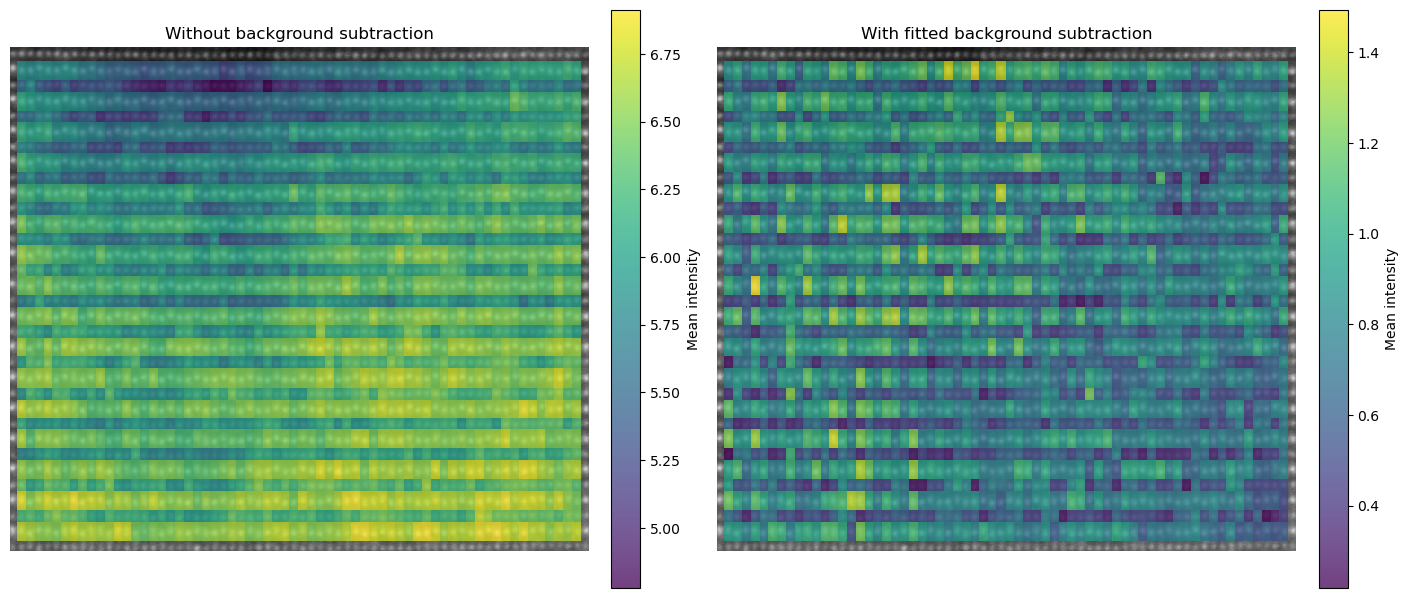

In [3]:
grid_creator = roi_tools.GridCreator()
layout = grid_creator.detect_layout(s)
grid = grid_creator.process(s, layout=layout)
mean_intensities_raw = grid.values(metric='mean_intensity')
backgrounds = roi_tools.subtract_background(grid)
mean_intensities_subtracted = grid.values(metric='mean_intensity')

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
plots = (
    ('Without background subtraction', mean_intensities_raw),
    ('With fitted background subtraction', mean_intensities_subtracted),
)

for ax, (title, values) in zip(axes, plots):
    plotter = roi_tools.PatchGridPlotter(s, grid, ax=ax)
    artist = plotter.add_patch_faces(
        values=values,
        cmap='viridis',
        alpha=0.75,
    )
    plotter.add_colorbar(artist, label='Mean intensity')
    ax.set_title(title)
    ax.axis('off')

plt.show()


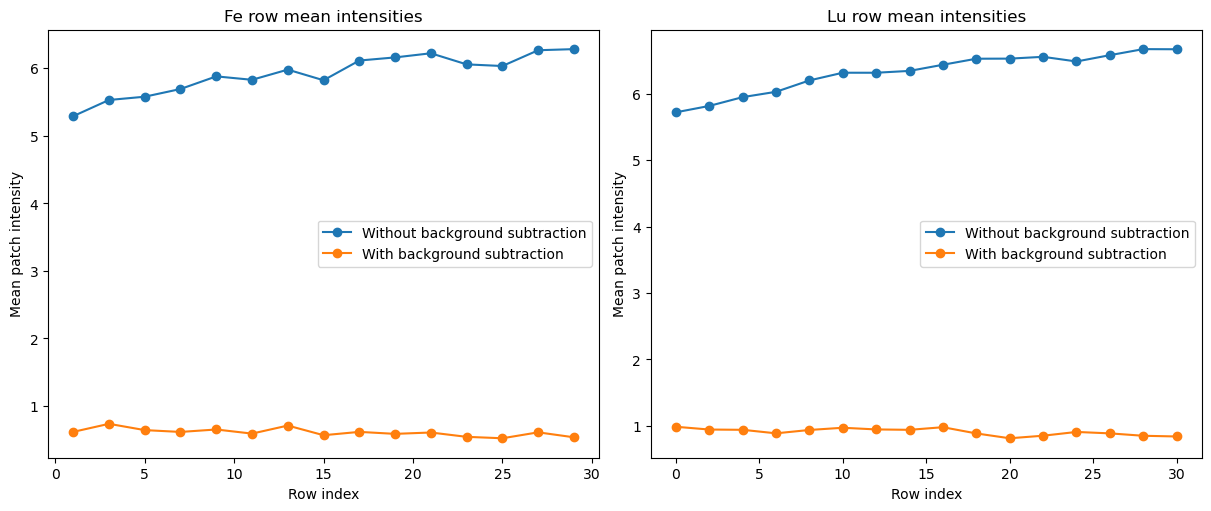

In [4]:
row_indices = np.arange(grid.shape[1])
row_atom_types = np.asarray(grid.atom_types[0])
if not np.all(grid.atom_types == row_atom_types):
    raise ValueError('Each row must contain a single atom type.')

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, atom_type in zip(axes, ('Fe', 'Lu')):
    selected_rows = row_atom_types == atom_type
    rows = row_indices[selected_rows]
    raw_row_means = mean_intensities_raw[:, selected_rows].mean(axis=0)
    subtracted_row_means = mean_intensities_subtracted[:, selected_rows].mean(axis=0)

    ax.plot(rows, raw_row_means, 'o-', label='Without background subtraction')
    ax.plot(rows, subtracted_row_means, 'o-', label='With background subtraction')
    ax.set_title(f'{atom_type} row mean intensities')
    ax.set_xlabel('Row index')
    ax.set_ylabel('Mean patch intensity')
    ax.legend()

plt.show()


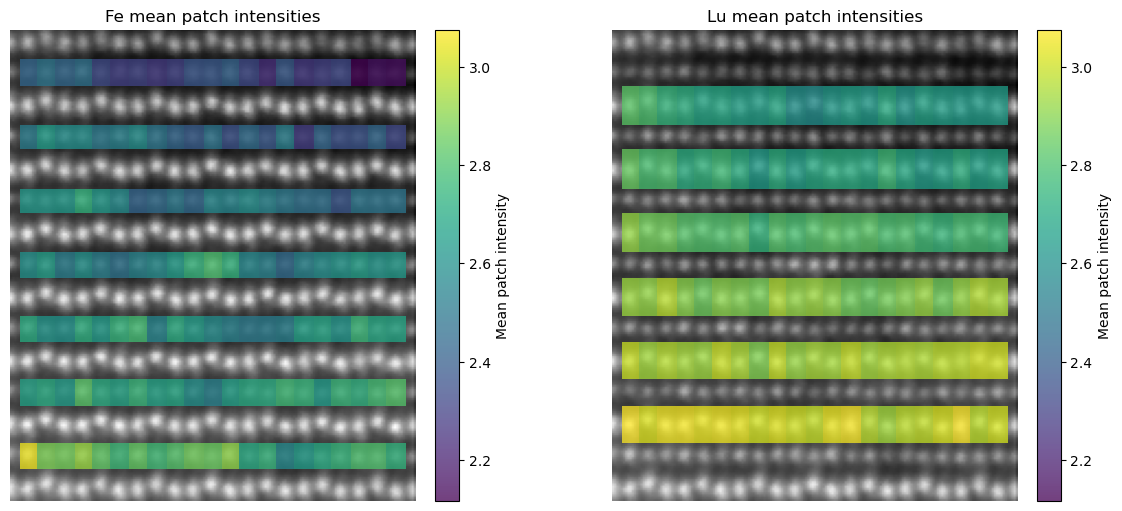

In [6]:
experimental_source = hs.load("../data/images/EELS/EEL SI 22 13/Integrated Shifted Spectrum Image adf.dm3")
experimental_signal = experimental_source.isig[0:185, 20:235]
experimental_layout = grid_creator.detect_layout(experimental_signal)
experimental_grid = grid_creator.process(
    experimental_signal, layout=experimental_layout
)
experimental_mean_intensities = experimental_grid.values(
    metric='mean_intensity'
)
vmin = experimental_mean_intensities.min()
vmax = experimental_mean_intensities.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, atom_type in zip(axes, ('Fe', 'Lu')):
    plotter = roi_tools.PatchGridPlotter(
        experimental_signal, experimental_grid, ax=ax
    )
    artist = plotter.add_patch_faces(
        atom_type=atom_type,
        values=experimental_mean_intensities,
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        alpha=0.75,
    )
    plotter.add_colorbar(artist, label='Mean patch intensity')
    ax.set_title(f'{atom_type} mean patch intensities')
    ax.axis('off')

plt.show()


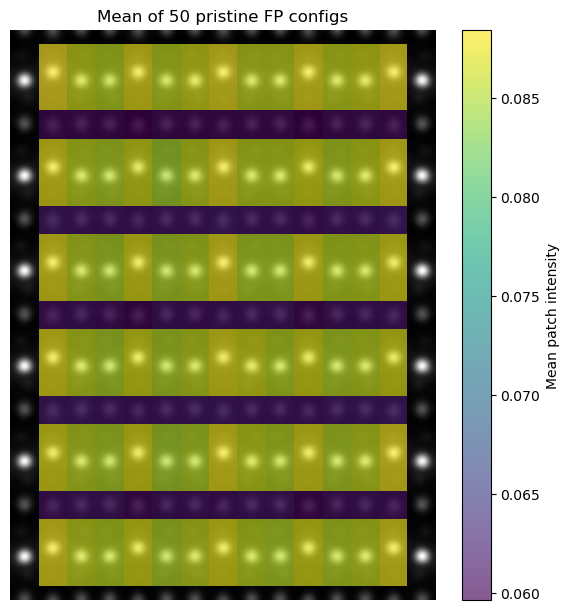

In [8]:
from pathlib import Path

pristine_dir = Path("../data/simulations/pristine_fp")
pristine_files = sorted(
    pristine_dir.glob("pristine_fp_*.npy"),
    key=lambda path: int(path.stem.rsplit("_", 1)[1]),
)[:50]
pristine_ensemble = np.stack([
    np.load(path).squeeze() for path in pristine_files
]).mean(axis=0)
pristine_signal = hs.signals.Signal2D(pristine_ensemble)
pristine_layout = grid_creator.detect_layout(pristine_signal)
pristine_grid = grid_creator.process(
    pristine_signal, layout=pristine_layout
)
pristine_mean_intensities = pristine_grid.values("mean_intensity")

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
pristine_plotter = roi_tools.PatchGridPlotter(
    pristine_signal, pristine_grid, ax=ax
)
artist = pristine_plotter.add_patch_faces(
    values=pristine_mean_intensities, cmap="viridis", alpha=0.65
)
pristine_plotter.add_colorbar(artist, label="Mean patch intensity")
ax.set_title("Mean of 50 pristine FP configs")
ax.axis("off")
plt.show()

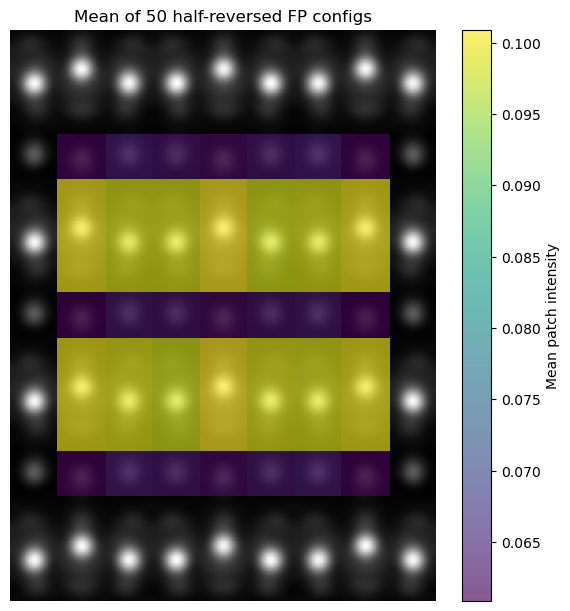

In [9]:
from pathlib import Path

pristine_dir = Path("../data/simulations/half_reversed_fp")
pristine_files = sorted(
    pristine_dir.glob("half_reversed_fp_*.npy"),
    key=lambda path: int(path.stem.rsplit("_", 1)[1]),
)[:50]
pristine_ensemble = np.stack([
    np.load(path).squeeze() for path in pristine_files
]).mean(axis=0)
pristine_signal = hs.signals.Signal2D(pristine_ensemble)
pristine_layout = grid_creator.detect_layout(pristine_signal)
pristine_grid = grid_creator.process(
    pristine_signal, layout=pristine_layout
)
pristine_mean_intensities = pristine_grid.values("mean_intensity")

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
pristine_plotter = roi_tools.PatchGridPlotter(
    pristine_signal, pristine_grid, ax=ax
)
artist = pristine_plotter.add_patch_faces(
    values=pristine_mean_intensities, cmap="viridis", alpha=0.65
)
pristine_plotter.add_colorbar(artist, label="Mean patch intensity")
ax.set_title("Mean of 50 half-reversed FP configs")
ax.axis("off")
plt.show()